<a href="https://colab.research.google.com/github/JAMZ-Fq/tecemer-lab1/blob/main/tareas/Ejercicio_03b_CNN_Deteccion_Objetos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3b — Redes Neuronales Convolucionales (CNN): Detección de Objetos
### Tecnologías Emergentes (ISO46B) — Material complementario de comprensión conceptual

Notebook **autocontenido** para **Google Colab** (`Entorno de ejecución > Ejecutar todas`). Usa **PyTorch + torchvision**, un modelo **preentrenado** (Faster R-CNN sobre COCO) y un par de imágenes de ejemplo descargadas por código — no requiere subir archivos.

**Objetivo:** entender la diferencia entre *clasificación* y *detección* de objetos, y cómo aplicar **transfer learning** con un modelo preentrenado para obtener resultados útiles sin entrenar una red desde cero (algo que normalmente requeriría miles de imágenes etiquetadas con cajas delimitadoras y muchas horas de GPU).

> **Nota sobre frameworks:** en las semanas anteriores usamos TensorFlow/Keras. Aquí usamos **PyTorch**, deliberadamente, porque en la práctica profesional ambos frameworks son ampliamente usados — TensorFlow/Keras es común en producción e industria, PyTorch domina en investigación y en el ecosistema de modelos preentrenados de visión (`torchvision`) y lenguaje (`transformers`). Saber leer ambos es una habilidad real del campo.


## 0. Configuración inicial

In [3]:
import io
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from PIL import Image

torch.manual_seed(42)
print("PyTorch:", torch.__version__, " | torchvision:", torchvision.__version__)
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", dispositivo)

PyTorch: 2.11.0+cu130  | torchvision: 0.26.0+cu130
Dispositivo: cuda


## 1. Clasificación vs. Detección — la diferencia clave

- **Clasificación de imágenes** (Notebook 3a): responde *"¿qué hay en esta imagen?"* — una sola etiqueta por imagen.
- **Detección de objetos**: responde *"¿qué objetos hay, y en qué parte exacta de la imagen está cada uno?"* — puede haber **varios objetos de distintas clases** en una misma imagen, cada uno con su propia **caja delimitadora (bounding box)**.

Un detector típico produce, para cada objeto encontrado:
1. Una **caja** `[x_min, y_min, x_max, y_max]`.
2. Una **clase** (ej. "perro", "persona", "bicicleta").
3. Un **puntaje de confianza** (0 a 1).

Internamente, arquitecturas como **Faster R-CNN** reutilizan una CNN clasificadora (como la del Notebook 3a) como "columna vertebral" (*backbone*) para extraer mapas de características, y le agregan dos módulos adicionales: uno que **propone regiones candidatas** donde podría haber un objeto, y otro que **clasifica y ajusta** la caja de cada región propuesta.

## 2. Cargar un modelo preentrenado (transfer learning)

Entrenar un detector desde cero requiere datasets masivos con cajas etiquetadas manualmente (COCO tiene ~330,000 imágenes). En su lugar, cargamos un **Faster R-CNN ya entrenado sobre COCO** (80 clases de objetos comunes) y lo usamos directamente para inferencia — esto **es** transfer learning: reutilizar el conocimiento que el modelo ya aprendió, sin volver a entrenarlo.

In [4]:
pesos = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
modelo = fasterrcnn_resnet50_fpn(weights=pesos, box_score_thresh=0.5)
modelo.eval().to(dispositivo)

CLASES_COCO = pesos.meta["categories"]
print(f"Modelo cargado. Puede reconocer {len(CLASES_COCO)} categorías, entre ellas:")
print(CLASES_COCO[1:15], "...")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 249MB/s]


Modelo cargado. Puede reconocer 91 categorías, entre ellas:
['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter'] ...


## 3. Cargar una imagen de ejemplo

Descargamos una imagen pública de prueba (del propio repositorio de ejemplos de `torchvision`).

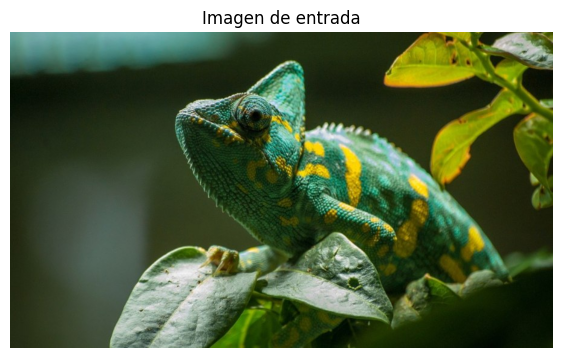

In [28]:
def cargar_imagen(url):
    respuesta = requests.get(url, timeout=15)
    return Image.open(io.BytesIO(respuesta.content)).convert("RGB")

url_imagen = "https://www.fundacionaquae.org/wp-content/uploads/2020/08/qu-animales-se-camuflan1.jpg"
imagen = cargar_imagen(url_imagen)

plt.figure(figsize=(7, 7))
plt.imshow(imagen)
plt.axis("off")
plt.title("Imagen de entrada")
plt.show()

## 4. Ejecutar la detección

In [29]:
transformar = transforms.Compose([transforms.ToTensor()])
tensor_imagen = transformar(imagen).to(dispositivo)

with torch.no_grad():
    predicciones = modelo([tensor_imagen])[0]

print("Claves de la predicción:", predicciones.keys())
print(f"Objetos detectados (antes de filtrar por confianza): {len(predicciones['boxes'])}")

Claves de la predicción: dict_keys(['boxes', 'labels', 'scores'])
Objetos detectados (antes de filtrar por confianza): 2


## 5. Visualizar las cajas delimitadoras

Filtramos por un **umbral de confianza** (solo mostramos detecciones en las que el modelo está razonablemente seguro) y dibujamos cada caja con su clase y puntaje.

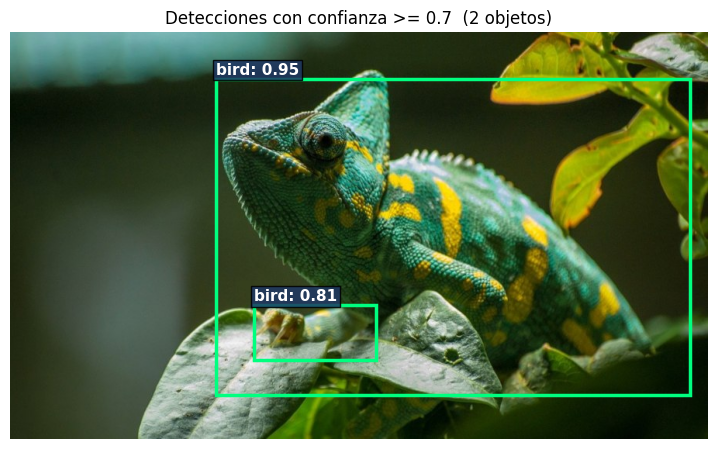

In [30]:
def dibujar_detecciones(imagen, predicciones, umbral=0.7, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(imagen)

    cajas = predicciones["boxes"].cpu().numpy()
    etiquetas = predicciones["labels"].cpu().numpy()
    puntajes = predicciones["scores"].cpu().numpy()

    n_mostradas = 0
    for caja, etiqueta, puntaje in zip(cajas, etiquetas, puntajes):
        if puntaje < umbral:
            continue
        x_min, y_min, x_max, y_max = caja
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                  linewidth=2.5, edgecolor="#00FF7F", facecolor="none")
        ax.add_patch(rect)
        nombre_clase = CLASES_COCO[etiqueta]
        ax.text(x_min, y_min - 6, f"{nombre_clase}: {puntaje:.2f}",
                color="white", fontsize=11, weight="bold",
                bbox=dict(facecolor="#1F3864", alpha=0.85, pad=2))
        n_mostradas += 1
    ax.set_title(f"Detecciones con confianza >= {umbral}  ({n_mostradas} objetos)")
    ax.axis("off")
    return n_mostradas

fig, ax = plt.subplots(figsize=(9, 9))
dibujar_detecciones(imagen, predicciones, umbral=0.7, ax=ax)
plt.show()

## 6. El efecto del umbral de confianza

Un umbral muy bajo muestra más objetos, pero también más falsos positivos. Un umbral muy alto es más "seguro" pero puede perder objetos reales (falsos negativos).

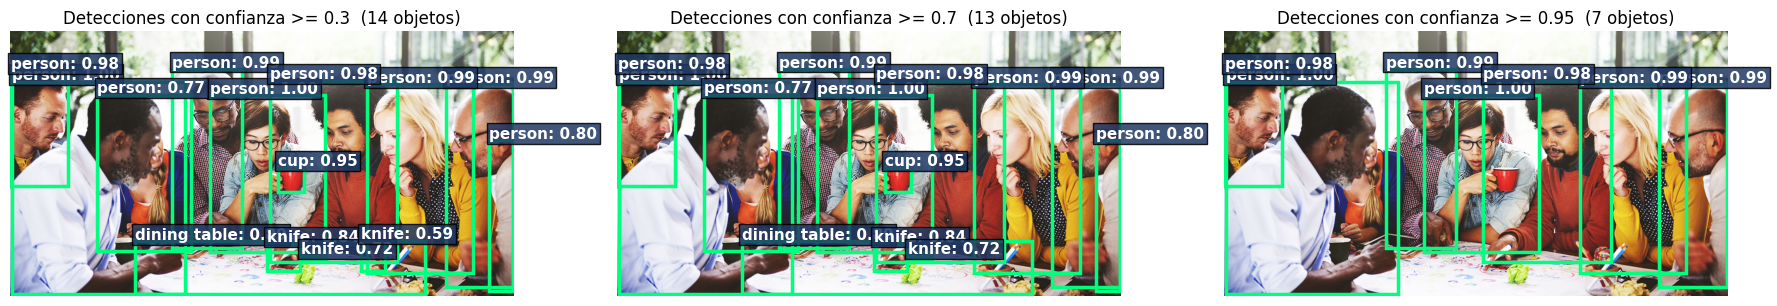

In [25]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 7))
for ax, umbral in zip(ejes, [0.3, 0.7, 0.95]):
    n = dibujar_detecciones(imagen, predicciones, umbral=umbral, ax=ax)
plt.tight_layout()
plt.show()

**Lectura:** con `umbral=0.3` suelen aparecer más cajas (algunas redundantes o erróneas); con `umbral=0.95` solo quedan las detecciones en las que el modelo está prácticamente seguro. Elegir el umbral correcto depende de la aplicación: en un sistema de seguridad quizás se prefiere un umbral bajo (mejor una falsa alarma que perder un evento real); en un contador automático de inventario, un umbral alto reduce errores de conteo.

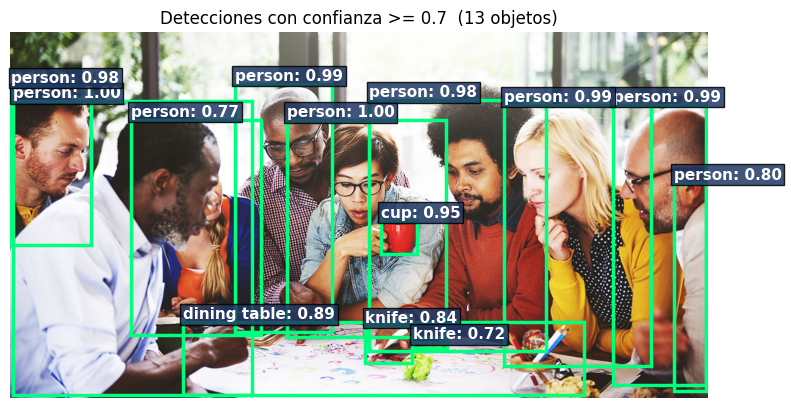

In [27]:
url_imagen_2 = "https://www.stopatnothing.com/wp-content/uploads/meeting-business-leaders.jpg"
imagen_2 = cargar_imagen(url_imagen_2)
tensor_imagen_2 = transformar(imagen_2).to(dispositivo)

with torch.no_grad():
    predicciones_2 = modelo([tensor_imagen_2])[0]

fig, ax = plt.subplots(figsize=(9, 9))
dibujar_detecciones(imagen_2, predicciones_2, umbral=0.7, ax=ax)
plt.show()

## 7. Segunda imagen — varias personas

## 8. Resumen

- La **detección de objetos** extiende la clasificación: localiza (caja) y clasifica **múltiples** objetos en una sola imagen.
- Modelos como **Faster R-CNN** reutilizan una CNN clasificadora como *backbone* y agregan cabezas especializadas para proponer regiones y ajustar cajas.
- Usar un modelo **preentrenado sobre COCO** (transfer learning) permite obtener detecciones útiles de inmediato, sin el costo de entrenar desde cero.
- El **umbral de confianza** es un parámetro de decisión, no del modelo: se ajusta según qué tipo de error (falso positivo vs. falso negativo) es más costoso para la aplicación.

Esta misma idea de transfer learning —reutilizar un modelo preentrenado en lugar de entrenar desde cero— reaparece en el Notebook 4c (descripción de imágenes) y es una práctica estándar en la industria cuando el dataset propio es pequeño.
